# Voyage Analytics — Customer Segmentation

Unsupervised segmentation of travelers using **KMeans** on travel-behaviour
features (trip frequency, spend, stay length, tenure). No target label —
the goal is to find natural groupings that could drive marketing / retention
strategy (e.g. "who are our VIPs?", "who's at risk of going quiet?").

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from data_prep import load_raw, build_user_features
from train_segmentation import FEATURES, train_segmentation

sns.set_style('whitegrid')
users, flights, hotels = load_raw()
user_features = build_user_features(users, flights, hotels)
user_features[FEATURES].describe()

,age,n_trips,avg_flight_price,total_flight_spend,avg_distance,n_hotel_bookings,avg_hotel_price,total_hotel_spend,avg_stay_days,total_spend,days_active
count,1340.000000,1340.000000,1335.000000,1340.000000,1335.000000,1340.000000,1310.000000,1340.000000,1310.000000,1340.000000,1340.000000
mean,42.742537,101.450746,956.369504,194252.822493,546.627494,30.262687,213.972505,16227.745679,2.504979,210480.568172,705.664925
std,12.869779,59.096760,93.594232,115100.547733,98.474143,18.354438,24.742681,10047.254861,0.314866,124516.659362,413.682651
min,21.000000,0.000000,575.877500,0.000000,168.220000,0.000000,60.390000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,50.000000,893.186948,95826.825000,469.949300,14.000000,201.173841,7466.262500,2.333333,103829.307500,344.000000
50%,42.000000,99.500000,933.502722,186947.745000,508.155838,29.000000,213.599500,16015.750000,2.500000,202335.955000,692.500000
75%,54.000000,155.000000,1038.472541,295389.630000,662.855353,46.000000,228.165743,24408.112500,2.647059,320162.315000,1079.250000
max,65.000000,200.000000,1654.540000,442901.020000,937.770000,76.000000,313.020000,40999.860000,4.000000,476952.820000,1397.000000


## 1. Choosing k with the elbow method + silhouette score

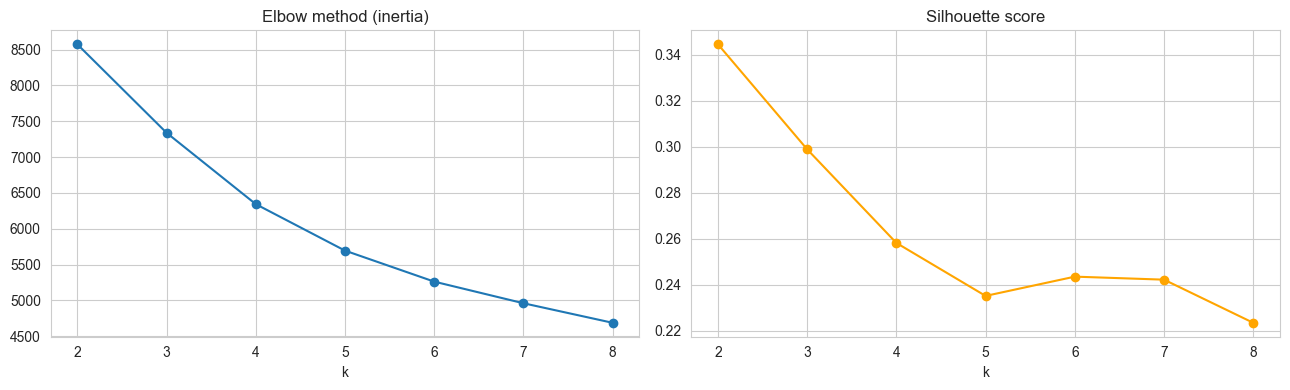

In [2]:
df = user_features.dropna(subset=FEATURES).copy()
X = df[FEATURES]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k')
axes[1].plot(list(K_range), sils, marker='o', color='orange')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

k=4 gives a reasonable elbow bend and a solid silhouette score without over-fragmenting the customer base into segments too small to act on.

## 2. Fit final model (k=4) and name segments

In [3]:
seg_df, kmeans, scaler, sil = train_segmentation(user_features, k=4)
print('Silhouette score:', round(sil, 3))

[Segmentation] k=4  silhouette=0.2582
segment_name
Occasional Traveler             435
Frequent Budget Traveler        410
Low-Engagement / At-Risk        239
High-Value Frequent Traveler    226
Name: count, dtype: int64
          age  n_trips  avg_flight_price  total_flight_spend  avg_distance  \
segment                                                                      
0        42.5     57.8             896.2            104125.4         475.2   
1        42.0    154.8            1054.6            326595.6         671.9   
2        43.5    155.9             909.4            283595.7         484.3   
3        42.5     49.4            1051.3            103735.8         660.2   

         n_hotel_bookings  avg_hotel_price  total_hotel_spend  avg_stay_days  \
segment                                                                        
0                    17.0            220.3             9286.0            2.5   
1                    47.0            205.0            24021.3         

In [4]:
seg_df['segment_name'].value_counts()

segment_name
Occasional Traveler             435
Frequent Budget Traveler        410
Low-Engagement / At-Risk        239
High-Value Frequent Traveler    226
Name: count, dtype: int64

In [5]:
profile = seg_df.groupby('segment_name')[FEATURES].mean().round(1)
profile

,age,n_trips,avg_flight_price,total_flight_spend,avg_distance,n_hotel_bookings,avg_hotel_price,total_hotel_spend,avg_stay_days,total_spend,days_active
segment_name,,,,,,,,,,,
Frequent Budget Traveler,43.5,155.9,909.4,283595.7,484.3,46.6,220.0,25662.7,2.5,309258.4,1087.1
High-Value Frequent Traveler,42.0,154.8,1054.6,326595.6,671.9,47.0,205.0,24021.3,2.5,350616.9,1079.2
Low-Engagement / At-Risk,42.5,49.4,1051.3,103735.8,660.2,14.3,200.6,7344.1,2.6,111079.9,341.0
Occasional Traveler,42.5,57.8,896.2,104125.4,475.2,17.0,220.3,9286.0,2.5,113411.4,400.4


## 3. Visualizing the segments

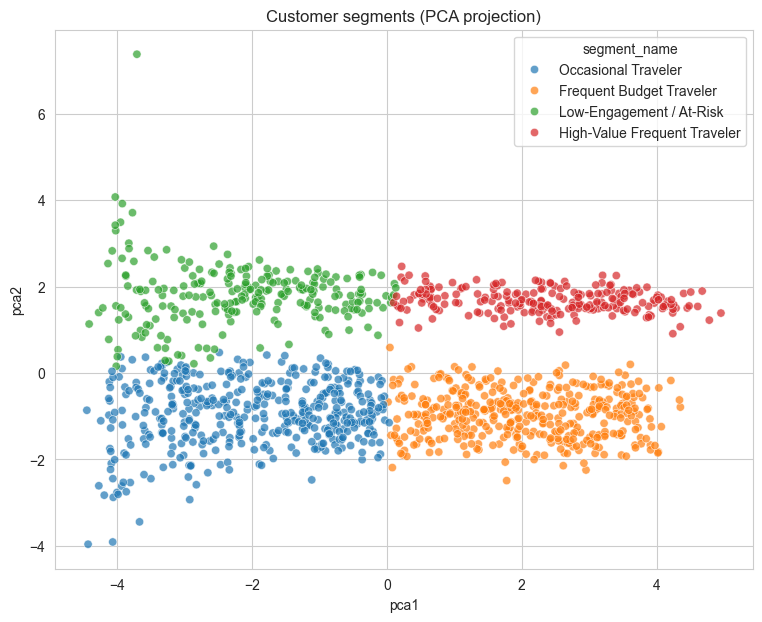

In [6]:
pca = PCA(n_components=2)
coords = pca.fit_transform(scaler.transform(seg_df[FEATURES]))
seg_df['pca1'], seg_df['pca2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=seg_df, x='pca1', y='pca2', hue='segment_name', alpha=0.7)
plt.title('Customer segments (PCA projection)')
plt.show()

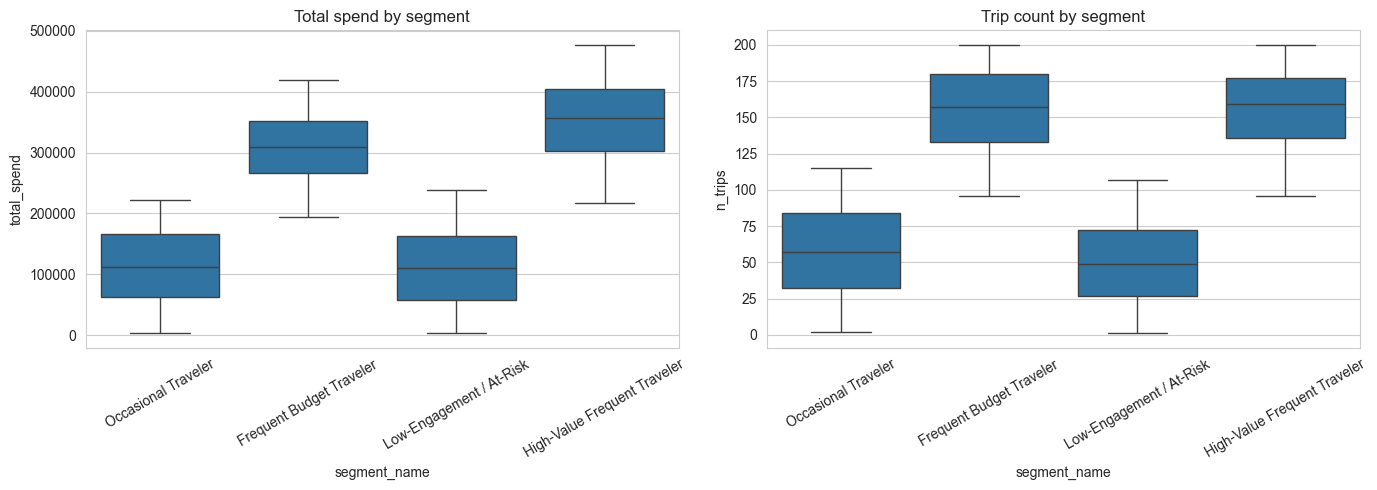

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=seg_df, x='segment_name', y='total_spend', ax=axes[0])
axes[0].set_title('Total spend by segment')
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=seg_df, x='segment_name', y='n_trips', ax=axes[1])
axes[1].set_title('Trip count by segment')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Business read-out

- **High-Value Frequent Traveler** — highest spend AND highest trip frequency. These are the customers a loyalty program should be built around.
- **Frequent Budget Traveler** — books often but spends less per trip; likely price-sensitive, good target for bundle upsells.
- **Occasional Traveler** — the largest or a mid-size group with moderate activity — the group most movable with targeted campaigns.
- **Low-Engagement / At-Risk** — lowest spend and shortest active window — candidates for a re-engagement push.

The fitted `scaler` + `kmeans` model, feature list, and segment name mapping are saved to
`models/segmentation_model.joblib`, and the full labelled table to `models/user_segments.csv`,
both consumed directly by the Streamlit app's "Customer Segments" page.